# Data Discretization & Binning Notes

**Definition:** The process of partitioning continuous numerical features into discrete intervals (bins/buckets) to transform them into categorical or ordinal features.

---

## 1. Key Strategies

| Strategy | Logic | Use Case |
| :--- | :--- | :--- |
| **Equal-Width** | Divides data into $N$ bins of equal size ($Range / N$). | Uniformly distributed data. |
| **Equal-Frequency** | Each bin contains the same number of observations (Quantiles). | Skewed data; handles outliers well. |
| **K-Means** | Uses 1D clustering to find natural "centers" for bins. | Multi-modal data (multiple peaks). |
| **Custom** | Manual boundaries based on domain expertise. | Age groups, credit scores, etc. |

---

## 2. Benefits vs. Drawbacks

### ✅ Pros
*   **Reduces Noise:** Smooths out minor fluctuations in data.
*   **Outlier Management:** Caps the impact of extreme values.
*   **Non-linearity:** Allows linear models to capture non-linear trends by treating intervals as distinct categories.
*   **Interpretability:** Simplifies reporting (e.g., "High Income" vs "$104,250.32").

### ❌ Cons
*   **Information Loss:** You lose the precise distance between data points.
*   **Boundary Effects:** Two very similar values (e.g., 0.49 and 0.51) may be assigned to different bins.
*   **Poor Bin Selection:** Choosing too few bins leads to underfitting; too many leads to overfitting.

---



## When to Use Binning

You should consider binning in the following scenarios:

- **Non-Linear Relationships:** When the relationship between a numerical feature and the target is not a straight line. For example, if "middle-aged" people behave differently than both "young" and "old" people, a linear model might struggle without age being binned into categories.
- **Noisy Data:** When your continuous data has minor measurement errors or random fluctuations. Binning smooths these out by grouping nearby values.
- **Impact of Outliers:** When extreme values disproportionately affect your model (common in linear regression). Binning "caps" these by putting them into a broader "high-value" bucket.
- **Clumpy Distributions:** When data naturally forms clusters rather than a smooth spread (e.g., latitude coordinates near cities).
- **High-Cardinality Features:** When a numerical feature has too many unique values for the model to learn effectively, binning can reduce this complexity.
- **Need for Interpretability:** When business logic or stakeholders require categorical groups (e.g., "Low," "Medium," and "High" income) instead of raw decimals.

---

## When to Avoid Binning

Avoid binning in these cases:

- **Deep Learning Models:** Neural networks are excellent at learning complex, non-linear patterns from raw numerical data and rarely benefit from pre-binning.
- **Tree-Based Models (Pre-binning):** Algorithms like Random Forest and XGBoost already perform their own internal binning (splits). Pre-binning can actually hurt them by restricting where they can place those splits.
- **Small Datasets:** Binning can reduce variance too much, leading to underfitting on small amounts of data.
- **Strong Linear Relationships:** If the raw number is already a perfect predictor, binning will only throw away useful precision.

---

## How to Choose the Right Binning Method

| Scenario | Recommended Method |
|--------|----------------------|
| Uniformly distributed data | **Equal-Width:** Simple intervals like 0–10, 11–20 |
| Skewed data or outliers | **Equal-Frequency (Quantile):** Each bin gets the same amount of data |
| Multimodal (multiple peaks) | **K-Means Binning:** Groups data based on natural clusters |
| Clear business/industry rules | **Custom Binning:** Manually defined based on domain expertise (e.g., age 0–18 = "Minor") |


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])

In [5]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
df.dropna(inplace=True)

In [7]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [10]:
clf = DecisionTreeClassifier()

In [11]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [12]:
accuracy_score(y_test,y_pred)

0.6083916083916084

In [13]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6331181533646322)

In [14]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [15]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [16]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

d:\AIML\venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\AIML\venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [17]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [18]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [19]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [20]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
118,24.00,5.0,247.5208,14.0,"(23.0, 25.0]","(108.9, 512.329]"
341,24.00,5.0,263.0000,14.0,"(23.0, 25.0]","(108.9, 512.329]"
831,0.83,0.0,18.7500,8.0,"(0.42, 6.0]","(14.454, 18.75]"
686,14.00,1.0,39.6875,11.0,"(6.0, 16.0]","(31.275, 51.479]"
57,28.50,7.0,7.2292,0.0,"(28.0, 30.0]","(0.0, 7.25]"


In [21]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()
    

0.6289514866979655


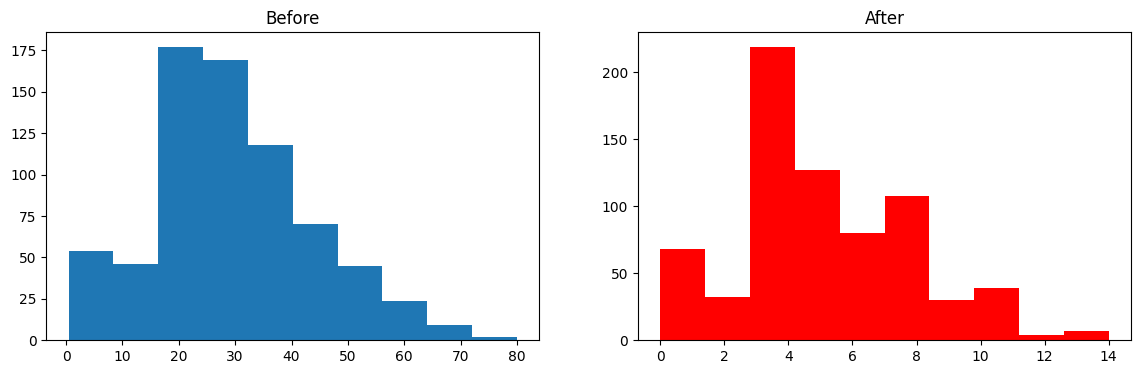

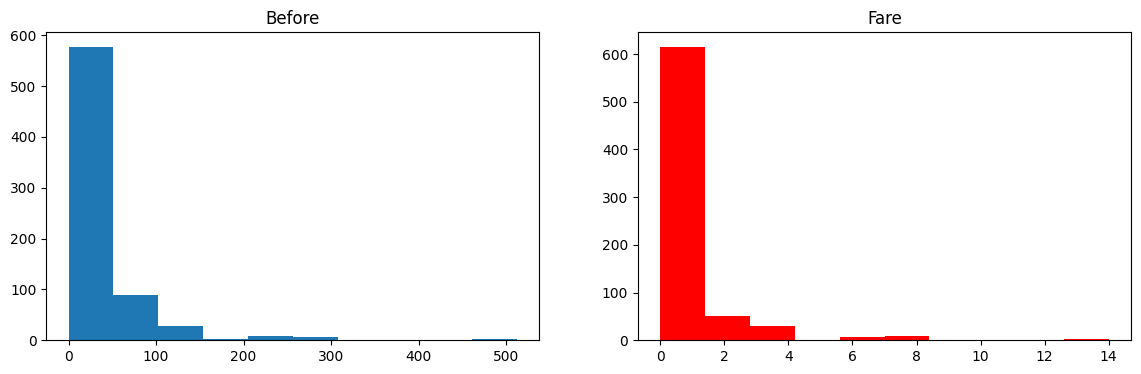

In [26]:
discretize(bins=15,strategy='uniform')

d:\AIML\venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\AIML\venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0.6275234741784037


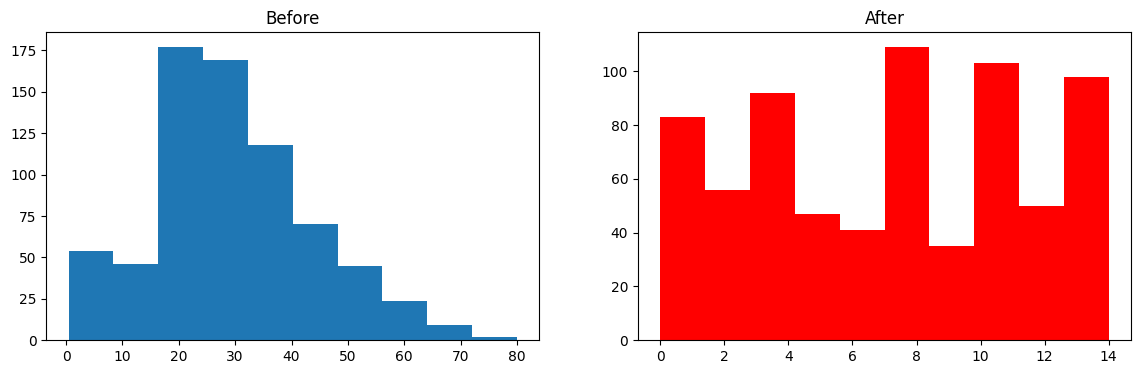

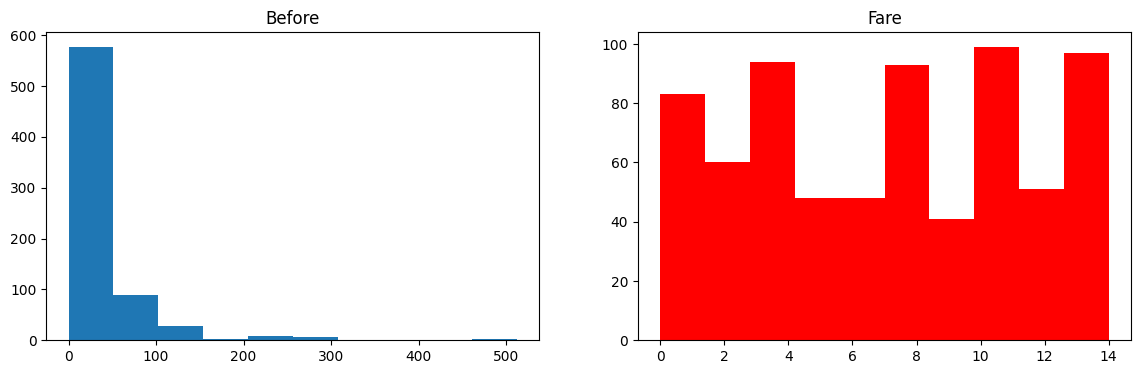

In [25]:
discretize(bins=15,strategy='quantile')

0.6316705790297339


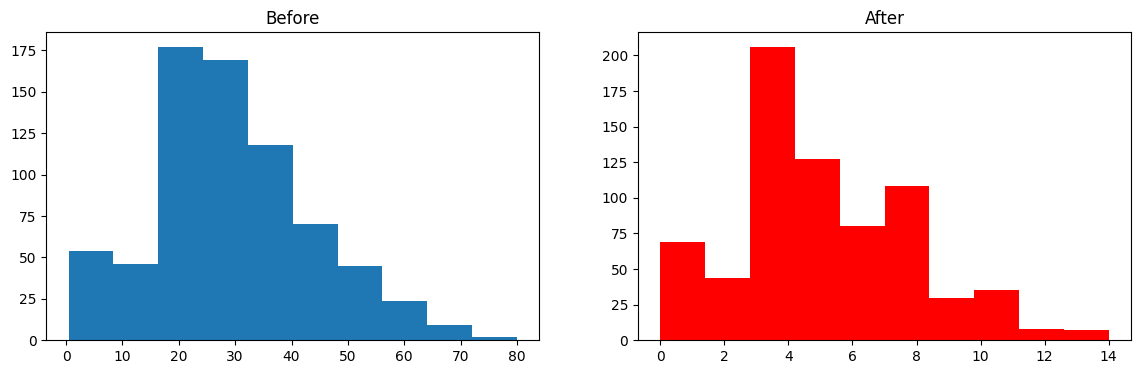

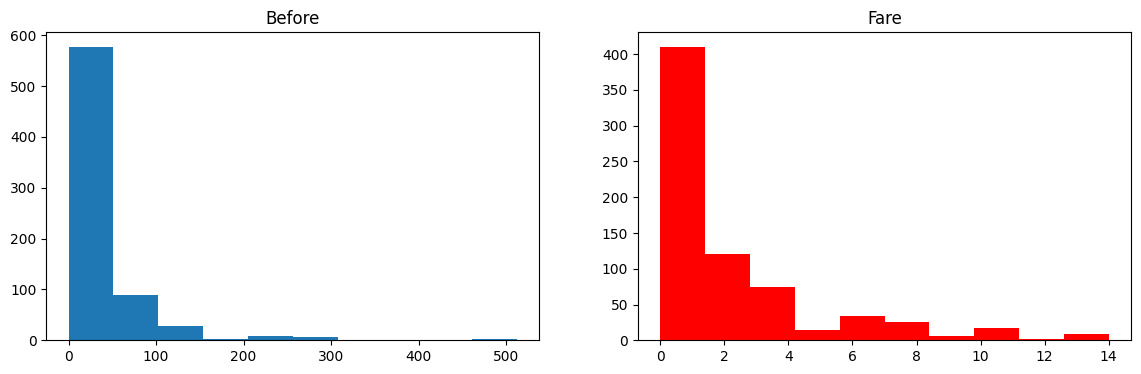

In [27]:
discretize(bins=15,strategy='kmeans')

## Binarization in Machine Learning

**Binarization** is a data preprocessing technique that converts numerical or categorical values into **binary values** (typically `0` and `1`). It is often used to simplify features, standardize inputs, or prepare data for models that work best with binary representations.

---

### 🔹 How It Works
Binarization applies a **threshold rule**:

\[
x_{binary} =
\begin{cases}
1 & \text{if } x > \text{threshold} \\
0 & \text{otherwise}
\end{cases}
\]

Example with threshold = 50:

| Original Value | Binary Output |
|----------------|---------------|
| 30 | 0 |
| 50 | 0 |
| 75 | 1 |
| 120 | 1 |

---

### 🔹 Why Use Binarization

- **Simplifies Data:** Reduces complex numeric ranges into simple signals.
- **Noise Reduction:** Small fluctuations below threshold are ignored.
- **Model Compatibility:** Some algorithms perform better with binary inputs (e.g., Bernoulli Naive Bayes).
- **Speed:** Binary features can speed up training and reduce memory usage.

---

### 🔹 Common Use Cases

- Converting grayscale images to black-and-white (image processing)
- Text classification using presence/absence of words
- Fraud detection flags (transaction above threshold → 1)
- Medical diagnosis indicators (test result positive → 1)

---

### 🔹 When to Avoid Binarization

- When numerical magnitude matters (e.g., predicting house prices)
- When threshold choice is arbitrary or subjective
- When binarization causes loss of useful detail

---

In [38]:
df = pd.read_csv('titanic.csv',usecols=['Age','Fare','SibSp','Parch','Survived'])

In [40]:
df.dropna(inplace=True)

In [41]:
df.head()

,Survived,Age,SibSp,Parch,Fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,0,35.0,0,0,8.0500


In [42]:
#add sibling spouse and family child 
df['family'] = df['SibSp'] + df['Parch']

In [43]:
df.head()

,Survived,Age,SibSp,Parch,Fare,family
0,0,22.0,1,0,7.2500,1
1,1,38.0,1,0,71.2833,1
2,1,26.0,0,0,7.9250,0
3,1,35.0,1,0,53.1000,1
4,0,35.0,0,0,8.0500,0


In [44]:
df.drop(columns=['SibSp','Parch'],inplace=True)

In [45]:
df.head()

,Survived,Age,Fare,family
0,0,22.0,7.2500,1
1,1,38.0,71.2833,1
2,1,26.0,7.9250,0
3,1,35.0,53.1000,1
4,0,35.0,8.0500,0


In [47]:
X = df.drop(columns=['Survived'])
y = df['Survived']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [48]:
X_train.head()

,Age,Fare,family
387,36.0,13.0000,0
685,25.0,41.5792,3
20,35.0,26.0000,0
331,45.5,28.5000,0
396,31.0,7.8542,0


In [49]:
# Without binarization

clf = DecisionTreeClassifier()

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

accuracy_score(y_test,y_pred)

0.6083916083916084

In [50]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6513693270735524)

In [51]:
# Applying Binarization

from sklearn.preprocessing import Binarizer

In [52]:
trf = ColumnTransformer([
    ('bin',Binarizer(copy=False),['family'])
],remainder='passthrough')

In [53]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [54]:
pd.DataFrame(X_train_trf,columns=['family','Age','Fare'])

,family,Age,Fare
0,0.0,36.0,13.0000
1,1.0,25.0,41.5792
2,0.0,35.0,26.0000
3,0.0,45.5,28.5000
4,0.0,31.0,7.8542
...,...,...,...
566,0.0,28.0,10.5000
567,0.0,19.0,10.5000
568,0.0,46.0,79.2000
569,1.0,26.0,7.8542


In [55]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

accuracy_score(y_test,y_pred2)

0.6293706293706294

In [56]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv=10,scoring='accuracy'))

np.float64(0.6233568075117372)